# Mouse Aging clustering analysis and annotation 

The Mouse Aging dataset [Jin et al] is a comprehensive single-cell RNA sequencing (scRNA-seq) dataset containing ~1.2 million high-quality single-cell transcriptomes of brain cells from young adult and aged mice of both sexes, from regions spanning the forebrain, midbrain, and hindbrain. High-resolution de novo clustering of all cells results in 847 cell clusters and reveals at least 14 age-biased clusters that are mostly glial types. Clusters in the study were mapped to the whole mouse brain taxonomy (WMB-taxonomy, [Yao et al.](https://www.biorxiv.org/content/10.1101/2023.03.06.531121v1)) to provide class, subclass and supertype annotations. At the broader cell subclass and supertype levels, age-associated gene expression signatures were analyzed resulting in a list of 2,449 differentially expressed genes (age-DE genes) for many neuronal and non-neuronal cell types. 

The purpose of this set of notebooks is to provide an overview of the data, the file organization, and how to combine data and metadata through example use cases.

You need to be connected to the internet to run this notebook or connected to a cache that has the Aging Mouse data downloaded already. Make sure to have run the `getting_started` notebook as well if you haven't already done so and familiarized yourself with the cache object.

The notebook presented here shows quick visualizations from precomputed metadata in the atlas. For examples on accessing the expression matrices, specifically selecting genes from expression matrices, see the ``general_acessing_10x_snRNASeq_tutorial.ipynb`` tutorial/example. 

In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import anndata
import matplotlib.pyplot as plt

from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

We will interact with the data using the AbcProjectCache. This cache object tracks which data has been downloaded and serves the path to the requested data on disk. For metadata, the cache can also directly serve up a Pandas Dataframe. See the [`getting_started`](https://alleninstitute.github.io/abc_atlas_access/notebooks/getting_started.html) notebook for more details on using the cache including installing it if it has not already been.  

Change the download_base variable to where you have downloaded the data in your system. 

In [2]:
download_base = Path('../../data/abc_atlas')
abc_cache = AbcProjectCache.from_cache_dir(download_base)

abc_cache.current_manifest

'releases/20250531/manifest.json'

## Data overview  

### Cell metadata  

Essential cell metadata is stored as a DataFrame. Each row represents one cell indexed by a *cell label*. The *cell label* is the concatenation of barcode and name of the sample. In this context, the sample is the *barcoded cell sample* that represents a single load into one port of the 10x Chromium. Note that cell barcodes are only unique within a single *barcoded cell sample* and that the same barcode can be reused. The *barcoded cell sample* label or name is unique in the database.  

Each cell is associated with a *library label*, *library method*, *donor label*, *donor sex*, dissection *region_of_interest_label*, the corresponding coarse *anatomical division label* and the *matrix_prefix* identifying which data package this cell is part of.  

Further, each cell is associated with a *cluster alias* representing which cluster this cell is a member of and (x, y) coordinates of the cells in the UMAP. 

Below, we load the first of the metadata used in this tutorial. This pattern of loading metadata is repeated throughout the tutorials. 

In [3]:
abc_cache.list_metadata_files('Zeng-Aging-Mouse-10Xv3')

['cell_annotation_colors',
 'cell_cluster_annotations',
 'cell_metadata',
 'cluster',
 'donor',
 'example_genes_all_cells_expression',
 'library',
 'value_sets']

In [4]:
abc_cache.list_metadata_files('Zeng-Aging-Mouse-WMB-taxonomy')

['aging_degenes',
 'cell_cluster_mapping_annotations',
 'cell_cross_mapping_annotations',
 'cluster_mapping',
 'cluster_mapping_pivot']

In [5]:
cell = abc_cache.get_metadata_dataframe(
    directory='Zeng-Aging-Mouse-10Xv3',
    file_name='cell_metadata',
    dtype={'cell_label': str,
           'wmb_cluster_alias': 'Int64'}
)
cell.set_index('cell_label', inplace=True)
print("Number of cells = ", len(cell))
cell.head()

Number of cells =  1162565


,cell_barcode,gene_count,umi_count,doublet_score,x,y,cluster_alias,cell_in_wmb_study,wmb_cluster_alias,library_label,...,donor_label,population_sampling,donor_genotype,donor_sex,donor_age,donor_age_category,donor_in_wmb_study,feature_matrix_label,dataset_label,abc_sample_id
cell_label,,,,,,,,,,,,,,,,,,,,,
AAACCCAAGGACACTG-367_B04,AAACCCAAGGACACTG,6176,26113.0,0.09,-2.288070,3.757430,273,True,1067,L8TX_200924_01_G05,...,Snap25-IRES2-Cre;Ai14-544400,unbiased,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,F,P58,adult,True,Zeng-Aging-Mouse-10Xv3,Zeng-Aging-Mouse-10Xv3,5ec753a4-d8b7-4ddf-a169-cc678ae9a073
AAACCCAAGTAAACGT-367_B04,AAACCCAAGTAAACGT,3717,10926.0,0.05,1.104098,11.232103,787,True,14939,L8TX_200924_01_G05,...,Snap25-IRES2-Cre;Ai14-544400,unbiased,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,F,P58,adult,True,Zeng-Aging-Mouse-10Xv3,Zeng-Aging-Mouse-10Xv3,7eca8d84-e6ad-4e09-98df-06eefd4b5bc3
AAACCCACATTGAGCT-367_B04,AAACCCACATTGAGCT,1358,2054.0,0.02,-2.465144,17.637245,833,True,5255,L8TX_200924_01_G05,...,Snap25-IRES2-Cre;Ai14-544400,unbiased,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,F,P58,adult,True,Zeng-Aging-Mouse-10Xv3,Zeng-Aging-Mouse-10Xv3,c69b1ea1-ce82-4396-a9c4-9e16eef19e9a
AAACGAAAGCCGTAAG-367_B04,AAACGAAAGCCGTAAG,3103,6899.0,0.03,1.328812,10.103676,787,True,14947,L8TX_200924_01_G05,...,Snap25-IRES2-Cre;Ai14-544400,unbiased,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,F,P58,adult,True,Zeng-Aging-Mouse-10Xv3,Zeng-Aging-Mouse-10Xv3,6a4b7938-43aa-4ccd-a1e2-3b9ed9fd3aac
AAACGAAAGCTACAAA-367_B04,AAACGAAAGCTACAAA,4459,16420.0,0.09,16.493496,2.265491,815,True,5230,L8TX_200924_01_G05,...,Snap25-IRES2-Cre;Ai14-544400,unbiased,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,F,P58,adult,True,Zeng-Aging-Mouse-10Xv3,Zeng-Aging-Mouse-10Xv3,55093777-2fe9-4f8a-b0e5-68a430f142d0


We can use pandas groupby function to see how many unique items are associated for each field and list them out if the number of items is small.

In [6]:
def print_column_info(df):
    
    for c in df.columns:
        grouped = df[[c]].groupby(c).count()
        members = ''
        if len(grouped) < 30:
            members = str(list(grouped.index))
        print("Number of unique %s = %d %s" % (c, len(grouped), members))

In [7]:
print_column_info(cell)

Number of unique cell_barcode = 997258 
Number of unique gene_count = 9838 
Number of unique umi_count = 81632 
Number of unique doublet_score = 874 
Number of unique x = 1147449 
Number of unique y = 1147537 
Number of unique cluster_alias = 847 
Number of unique cell_in_wmb_study = 2 [False, True]
Number of unique wmb_cluster_alias = 2656 
Number of unique library_label = 287 
Number of unique alignment_job_id = 287 
Number of unique library_method = 2 ['10Xv3', '10xV3.1']
Number of unique barcoded_cell_sample_label = 287 
Number of unique enrichment_population = 6 ['Calcein-positive, Hoechst-positive', 'Hoechst-positive', 'No FACS', 'RFP-positive, Calcein-positive, Hoechst-positive', 'RFP-positive, DAPI-negative', 'RFP-positive, Hoechst-positive']
Number of unique region_of_interest_label = 16 ['HPF - ENT', 'HPF - HIP', 'HPF - PAR-POST-PRE-SUB-ProS', 'HY - HY', 'Iscortex  - ACA', 'Isocortex  - AI', 'Isocortex - PL-ILA-ORB', 'Isocortex - RSP', 'MB - PAG-RAmb', 'MB - VTA-SN', 'P - Pmo

#### Cell metadata colors 

Below we load a DataFrame containing name and color mappings pre-cell for donor sex, region of interest, and anatomical division. This DataFrame is indexed by cell the same as the above cell_metadata. This allows us to label the UMAP with the previously mentioned distinct labels. 

In [8]:
cell_colors = abc_cache.get_metadata_dataframe(
    directory='Zeng-Aging-Mouse-10Xv3',
    file_name='cell_annotation_colors'
).set_index('cell_label')
cell_colors.head()

,anatomical_division_color,anatomical_division_order,donor_age_category_color,donor_age_category_order,donor_sex_color,donor_sex_order,region_of_interest_color,region_of_interest_order
cell_label,,,,,,,,
AAACCCAAGGACACTG-367_B04,#98D6F9,2,#9ACA3C,0,#FAAA5B,0,#98D6F9,7
AAACCCAAGTAAACGT-367_B04,#98D6F9,2,#9ACA3C,0,#FAAA5B,0,#98D6F9,7
AAACCCACATTGAGCT-367_B04,#98D6F9,2,#9ACA3C,0,#FAAA5B,0,#98D6F9,7
AAACGAAAGCCGTAAG-367_B04,#98D6F9,2,#9ACA3C,0,#FAAA5B,0,#98D6F9,7
AAACGAAAGCTACAAA-367_B04,#98D6F9,2,#9ACA3C,0,#FAAA5B,0,#98D6F9,7


We will merge these two DataFrames to create one that contains both cell metadata and color information, ready to plot on a UMAP. We also shuffle the cell metadata to get a more representative plot in the UMAP. This is done as the default DataFrame is sorted cell_id which correlates with some of the metadata (e.g. age). 

In [9]:
cell_extended = cell.join(cell_colors, rsuffix='_cl_colors')
cell_extended = cell_extended.sample(frac=1, random_state=12345)
cell_extended.head()

,cell_barcode,gene_count,umi_count,doublet_score,x,y,cluster_alias,cell_in_wmb_study,wmb_cluster_alias,library_label,...,dataset_label,abc_sample_id,anatomical_division_color,anatomical_division_order,donor_age_category_color,donor_age_category_order,donor_sex_color,donor_sex_order,region_of_interest_color,region_of_interest_order
cell_label,,,,,,,,,,,,,,,,,,,,,
GCCTGTTGTGAATTAG-135_B01,GCCTGTTGTGAATTAG,6777,37834.0,0.200000,-1.185296,1.881103,278,True,1079,L8TX_190716_01_D07,...,Zeng-Aging-Mouse-10Xv3,b801b060-42b7-465c-a768-1a9b8dd9de7f,#98D6F9,2,#9ACA3C,0,#FAAA5B,0,#80CDF8,8
TCCGAAAGTGAAGCGT-761_A04,TCCGAAAGTGAAGCGT,3396,9585.0,0.030303,14.007499,-0.220336,817,False,<NA>,L8TX_210805_01_H01,...,Zeng-Aging-Mouse-10Xv3,a59a8bc8-3c52-4d77-bebf-4ebf31e8d079,#7ED04B,1,#CC6828,1,#FAAA5B,0,#7ED04B,4
TTACCATGTCGTGGTC-327_A06,TTACCATGTCGTGGTC,4294,10527.0,0.020000,6.550781,-1.378886,804,False,<NA>,L8TX_200813_01_H10,...,Zeng-Aging-Mouse-10Xv3,2e5da533-b920-4707-aba1-d27f04ce5018,#8599CC,3,#CC6828,1,#735AA6,1,#8599CC,10
ACGGGTCGTACGAGCA-385_D06,ACGGGTCGTACGAGCA,2943,6957.0,0.000000,13.650183,0.289086,817,False,<NA>,L8TX_201008_01_A12,...,Zeng-Aging-Mouse-10Xv3,8b63cdce-4d15-4e88-b154-c29fd0e23ff1,#E64438,4,#CC6828,1,#735AA6,1,#E64438,11
CTTAGGATCTGTCCCA-301_B04,CTTAGGATCTGTCCCA,7907,47406.0,0.037037,6.583878,-10.639808,152,False,<NA>,L8TX_200723_01_B10,...,Zeng-Aging-Mouse-10Xv3,8c290798-5c6e-42d9-a906-bfb69ec4399b,#7ED04B,1,#CC6828,1,#FAAA5B,0,#72D569,6


### UMAP spatial embedding: Donor and anatomic information  

Now that we've merged the color information into the main cells data, we can plot the Uniform Manifold Approximation and Projection (UMAP) for all the cells in the dataset. The UMAP is a dimension reduction technique that can be used for visualizing and exploring large-dimension datasets. The x and y columns of the cell metadata table represent the coordinate of all cells in the UMAP in Figure 1 of the manuscript.  

We define a small helper function *plot umap* to visualize the cells on the UMAP. In this example will plot associated cell information colorized by dissection region of interest, neurotransmitter identity, sex, taxonomy level, age category, and age depletion/enrichment. 

In [10]:
def plot_umap(xx, yy, cc=None, val=None, fig_width=8, fig_height=8, cmap=None, labels=None):

    fig, ax = plt.subplots()
    fig.set_size_inches(fig_width, fig_height)

    if cmap is not None:
        scatt = ax.scatter(xx, yy, c=val, s=0.5, marker='.', cmap=cmap)
    elif cc is not None:
        scatt = ax.scatter(xx, yy, c=cc, s=0.5, marker='.')

    if labels is not None:
        from matplotlib.patches import Rectangle
        unique_colors = cc.unique()
        rects = []
        for color in unique_colors:
            rects.append(Rectangle((0, 0), 1, 1, fc=color))

        legend = ax.legend(rects, labels, loc=0)
        # ax.add_artist(legend)

    ax.axis('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    
    return fig, ax

Below we plot the UMAPS for each of anatomical division, dissection, sex, and age. 

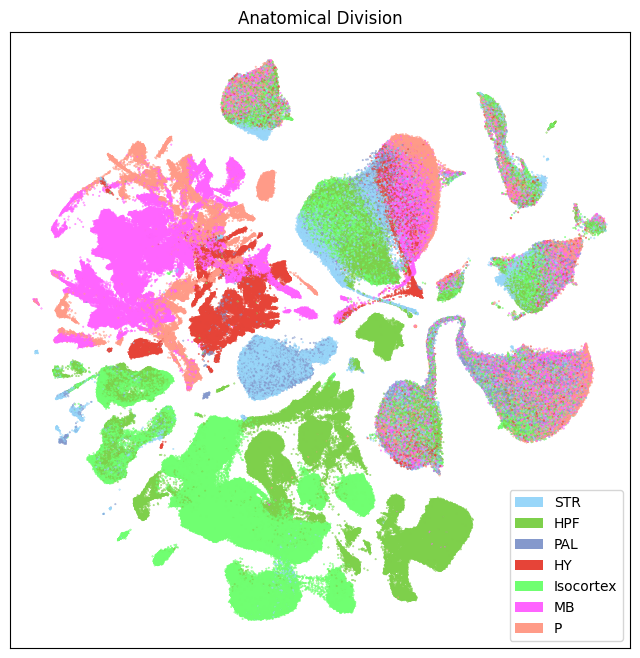

In [11]:
fig, ax = plot_umap(
    cell_extended['x'],
    cell_extended['y'],
    cc=cell_extended['anatomical_division_color'],
    labels=cell_extended['anatomical_division_label'].unique()
)
res = ax.set_title("Anatomical Division")
plt.show()

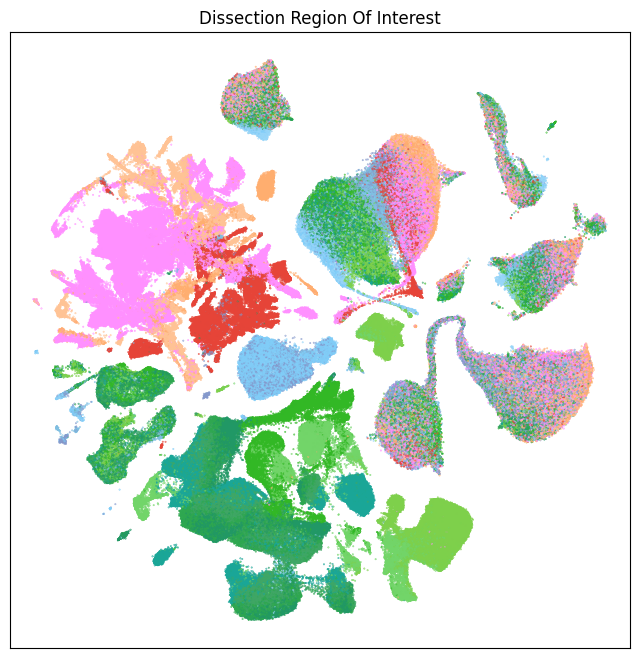

In [12]:
fig, ax = plot_umap(
    cell_extended['x'],
    cell_extended['y'],
    cc=cell_extended['region_of_interest_color']
)
res = ax.set_title("Dissection Region Of Interest")
plt.show()

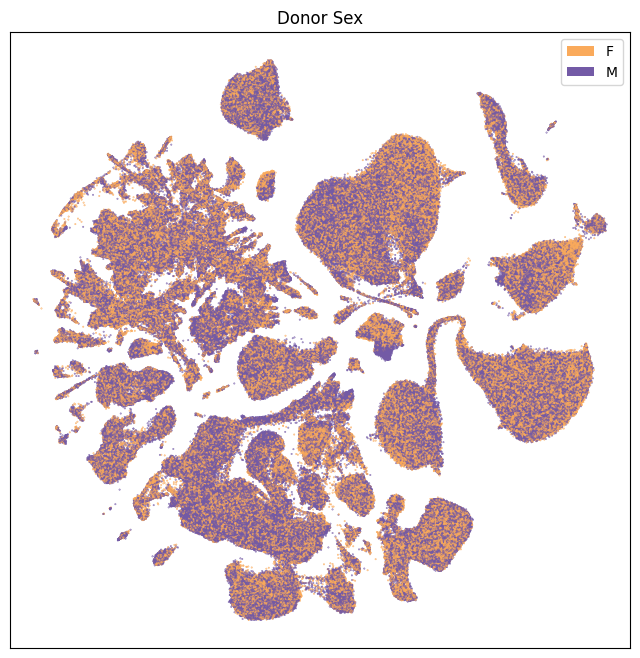

In [13]:
fig, ax = plot_umap(
    cell_extended['x'],
    cell_extended['y'],
    cc=cell_extended['donor_sex_color'],
    labels=cell_extended['donor_sex'].unique()
)
res = ax.set_title("Donor Sex")
plt.show()

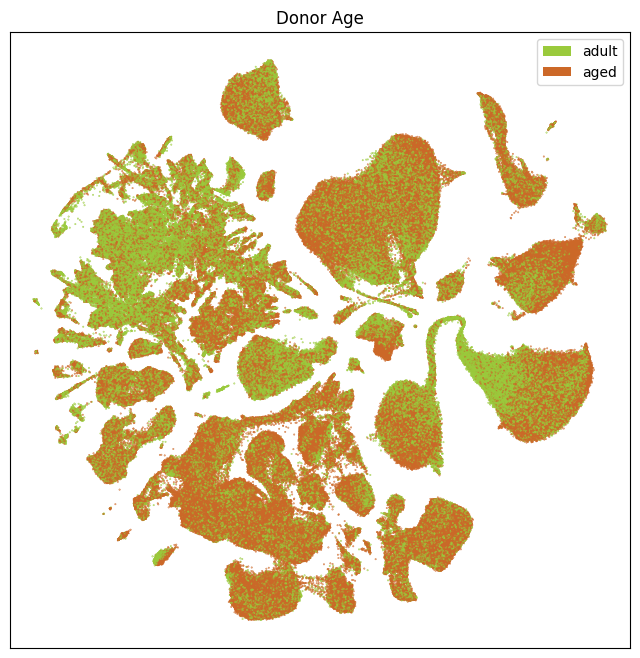

In [14]:
fig, ax = plot_umap(
    cell_extended['x'],
    cell_extended['y'],
    cc=cell_extended['donor_age_category_color'],
    labels=cell_extended['donor_age_category'].unique()
)
res = ax.set_title("Donor Age")
plt.show()

##  Cluster Metadata

We load information on the individual clusters including the age ratio, odds, and neurotransmitter information. This metadata is indexed on cluster_alias which is also a column in the cell_metadata that allows us to merge the information into that DataFrame. 

In [15]:
cluster_info = abc_cache.get_metadata_dataframe(
    directory='Zeng-Aging-Mouse-10Xv3',
    file_name='cluster'
).set_index('cluster_alias')
cluster_info.head()

,number_of_cells,cluster_label,cluster_order,cluster_name,cluster_color,max_region_of_interest_label,proportion_max_region_of_interest_label,number_of_adult_cells,number_of_aged_cells,proportion_adult_cells,proportion_aged_cells,odds_ratio,log2_odds_ratio,cluster_age_bias,max_region_of_interest_color,cluster_age_bias_color,neurotransmitter_combined_label,neurotransmitter_label,neurotransmitter_color
cluster_alias,,,,,,,,,,,,,,,,,,,
1,851,CS20241021_0001,0,1_CLA-EPd-CTX Car3 Glut_1,#f7c27a,Isocortex - AI,0.831962,183,668,0.215041,0.784959,1.453797,0.539826,unassigned,#219866,#DADEDF,Glut,Glut,#2B93DF
2,330,CS20241021_0002,1,2_IT EP-CLA Glut_1,#5c1a34,Isocortex - AI,0.969697,160,170,0.484848,0.515152,0.421595,-1.246071,unassigned,#219866,#DADEDF,Glut,Glut,#2B93DF
3,589,CS20241021_0003,2,3_IT EP-CLA Glut_1,#b96cf0,Isocortex - AI,0.894737,240,349,0.407470,0.592530,0.576896,-0.793616,unassigned,#219866,#DADEDF,Glut,Glut,#2B93DF
4,207,CS20241021_0004,3,4_IT EP-CLA Glut_1,#bff691,Isocortex - AI,0.971014,107,100,0.516908,0.483092,0.371035,-1.430373,unassigned,#219866,#DADEDF,Glut,Glut,#2B93DF
5,2141,CS20241021_0005,4,5_IT EP-CLA Glut_1,#39fbfa,Isocortex - AI,0.987389,655,1486,0.305932,0.694068,0.900735,-0.150825,unassigned,#219866,#DADEDF,Glut,Glut,#2B93DF


Now that we have our data loaded and indexed, we can merge the tables together to create a single DataFrame allowing us to plot various information onto the UMAP and beyond. 

In [16]:
# Join the cluster information in by joining on the Aging dataset's cluster_alias column.
cell_extended = cell_extended.join(cluster_info, on='cluster_alias', rsuffix='_cl_info')
cell_extended.head()

,cell_barcode,gene_count,umi_count,doublet_score,x,y,cluster_alias,cell_in_wmb_study,wmb_cluster_alias,library_label,...,proportion_adult_cells,proportion_aged_cells,odds_ratio,log2_odds_ratio,cluster_age_bias,max_region_of_interest_color,cluster_age_bias_color,neurotransmitter_combined_label,neurotransmitter_label,neurotransmitter_color
cell_label,,,,,,,,,,,,,,,,,,,,,
GCCTGTTGTGAATTAG-135_B01,GCCTGTTGTGAATTAG,6777,37834.0,0.200000,-1.185296,1.881103,278,True,1079,L8TX_190716_01_D07,...,0.577949,0.422051,1.013716,0.019653,unassigned,#80CDF8,#DADEDF,GABA,GABA,#FF3358
TCCGAAAGTGAAGCGT-761_A04,TCCGAAAGTGAAGCGT,3396,9585.0,0.030303,14.007499,-0.220336,817,False,<NA>,L8TX_210805_01_H01,...,0.454494,0.545506,1.046448,0.065500,unassigned,#8599CC,#DADEDF,No-NT,No-NT,#666666
TTACCATGTCGTGGTC-327_A06,TTACCATGTCGTGGTC,4294,10527.0,0.020000,6.550781,-1.378886,804,False,<NA>,L8TX_200813_01_H10,...,0.370570,0.629430,1.741208,0.800089,unassigned,#80C0E2,#DADEDF,No-NT,No-NT,#666666
ACGGGTCGTACGAGCA-385_D06,ACGGGTCGTACGAGCA,2943,6957.0,0.000000,13.650183,0.289086,817,False,<NA>,L8TX_201008_01_A12,...,0.454494,0.545506,1.046448,0.065500,unassigned,#8599CC,#DADEDF,No-NT,No-NT,#666666
CTTAGGATCTGTCCCA-301_B04,CTTAGGATCTGTCCCA,7907,47406.0,0.037037,6.583878,-10.639808,152,False,<NA>,L8TX_200723_01_B10,...,0.403409,0.596591,0.587232,-0.767999,unassigned,#72D569,#DADEDF,Glut,Glut,#2B93DF


### UMAP: Taxonomy information

Below are UMAPs for labels associated with the taxonomy, namely: neurotransmitter and cluster. Note that the colors for neurotransmitter (and for class, subclass, and supertype) are the same as those from the WMB taxonomy.

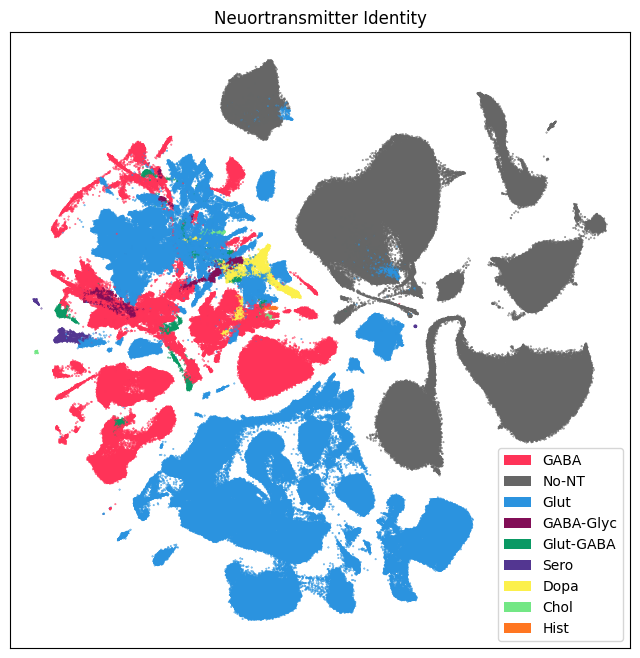

In [17]:
fig, ax = plot_umap(
    cell_extended['x'],
    cell_extended['y'],
    cc=cell_extended['neurotransmitter_color'],
    labels=cell_extended['neurotransmitter_label'].unique()
)
res = ax.set_title("Neuortransmitter Identity")
plt.show()

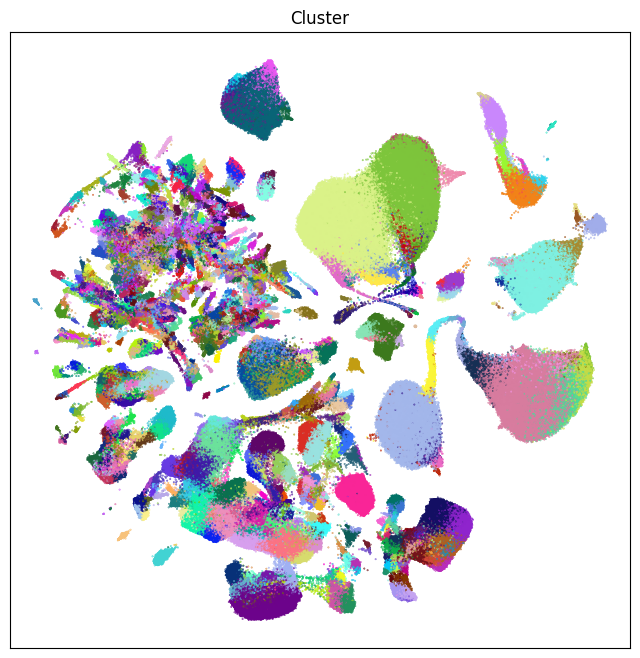

In [18]:
fig, ax = plot_umap(cell_extended['x'], cell_extended['y'], cc=cell_extended['cluster_color'])
res = ax.set_title("Cluster")
plt.show()

#### Aging information 

We plot aging related information on our UMAP, showing the different age-related variables and they are expressed in different locations of the UMAP. Below we show the location of the cells from the adult and aged mice. 

Next, we show the log of the cluster level odds ratio for a given cluster to be age enriched (brown) or depleted (blue-green). 

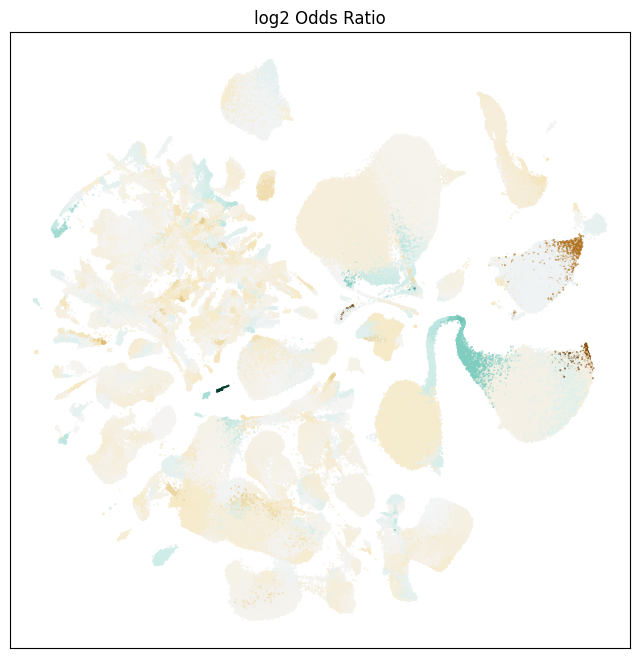

In [19]:
fig, ax = plot_umap(
    cell_extended['x'],
    cell_extended['y'],
    val=cell_extended['log2_odds_ratio'],
    cmap='BrBG_r'
)
res = ax.set_title("log2 Odds Ratio")
plt.show()

Finally, we show the clusters that are identified as aging-enriched and aging-depleted based on their odds ratio. (-2.5 > log2_odds_ratio, log2_odds_ratio > 2.5). 

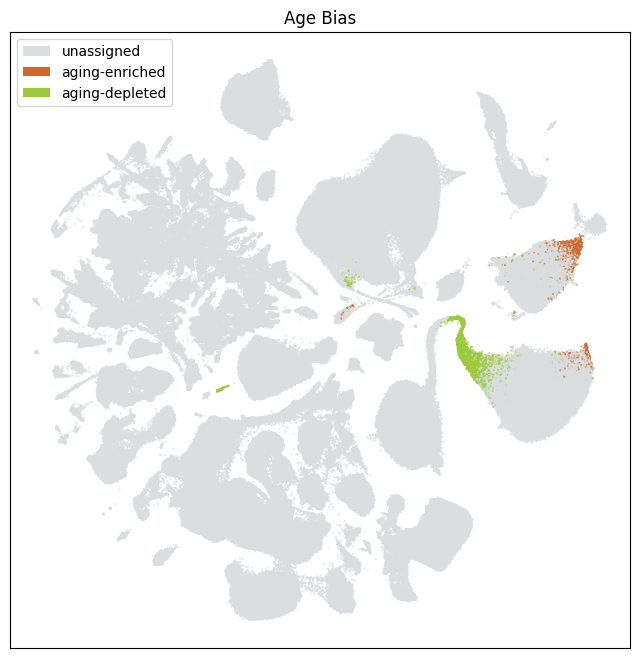

In [20]:
fig, ax = plot_umap(
    cell_extended['x'],
    cell_extended['y'],
    cc=cell_extended['cluster_age_bias_color'],
    labels=cell_extended['cluster_age_bias'].unique()
)
res = ax.set_title("Age Bias")
plt.show()

## Taxonomy Mapping

The following metadata maps all cells to the clusters and above levels in the taxonomy hierarchy. This includes all names and colors for each part of the taxonomy. As show in the above cluster tutorial for this dataset, each cluster in the Aging Dataset is nested within a supertype from the WMB dataset allowing one to walk all the way up to the class level.

In [21]:
cell_cluster_mapping = abc_cache.get_metadata_dataframe(
    directory='Zeng-Aging-Mouse-WMB-taxonomy',
    file_name='cell_cluster_mapping_annotations'
).set_index('cell_label')
cell_cluster_mapping.head()

,cluster_alias,cluster_label,cluster_order,cluster_name,cluster_color,class_name,subclass_name,supertype_name,class_color,subclass_color,supertype_color
cell_label,,,,,,,,,,,
AAACCCAAGGACACTG-367_B04,273,CS20241021_0273,272,273_STR D1 Gaba_8,#669ff8,09 CNU-LGE GABA,061 STR D1 Gaba,0272 STR D1 Gaba_8,#B199FF,#005B66,#660F13
AAACCCAAGTAAACGT-367_B04,787,CS20241021_0787,786,787_Astro-TE NN_3,#daf288,30 Astro-Epen,319 Astro-TE NN,1163 Astro-TE NN_3,#594a26,#3DCCB1,#a8afa5
AAACCCACATTGAGCT-367_B04,833,CS20241021_0833,832,833_Endo NN_1,#096577,33 Vascular,333 Endo NN,1193 Endo NN_1,#858881,#994567,#00992A
AAACGAAAGCCGTAAG-367_B04,787,CS20241021_0787,786,787_Astro-TE NN_3,#daf288,30 Astro-Epen,319 Astro-TE NN,1163 Astro-TE NN_3,#594a26,#3DCCB1,#a8afa5
AAACGAAAGCTACAAA-367_B04,815,CS20241021_0815,814,815_MOL NN_4,#c4dd47,31 OPC-Oligo,327 Oligo NN,1184 MOL NN_4,#03045E,#99FFBC,#99CAFF


In [22]:
cell_extended = cell_extended.join(cell_cluster_mapping, rsuffix='_cl_map')

# Quick run through to drop duplicated columns
drop_cols = []
for col in cell_extended.columns:
    if col.endswith(('_cl_map', '_cl_colors', '_cl_info')):
        drop_cols.append(col)
cell_extended.drop(columns=drop_cols, inplace=True)

Let's take a look at what columns and data are in our final combined DataFrame before our final UMAP plots.

In [23]:
print_column_info(cell_extended)

Number of unique cell_barcode = 997258 
Number of unique gene_count = 9838 
Number of unique umi_count = 81632 
Number of unique doublet_score = 874 
Number of unique x = 1147449 
Number of unique y = 1147537 
Number of unique cluster_alias = 847 
Number of unique cell_in_wmb_study = 2 [False, True]
Number of unique wmb_cluster_alias = 2656 
Number of unique library_label = 287 
Number of unique alignment_job_id = 287 
Number of unique library_method = 2 ['10Xv3', '10xV3.1']
Number of unique barcoded_cell_sample_label = 287 
Number of unique enrichment_population = 6 ['Calcein-positive, Hoechst-positive', 'Hoechst-positive', 'No FACS', 'RFP-positive, Calcein-positive, Hoechst-positive', 'RFP-positive, DAPI-negative', 'RFP-positive, Hoechst-positive']
Number of unique region_of_interest_label = 16 ['HPF - ENT', 'HPF - HIP', 'HPF - PAR-POST-PRE-SUB-ProS', 'HY - HY', 'Iscortex  - ACA', 'Isocortex  - AI', 'Isocortex - PL-ILA-ORB', 'Isocortex - RSP', 'MB - PAG-RAmb', 'MB - VTA-SN', 'P - Pmo

Now that the information on the WMB taxonomy has been merged into our cell metadata, we plot them here. Note again that the colors here are the same as those in WMB.

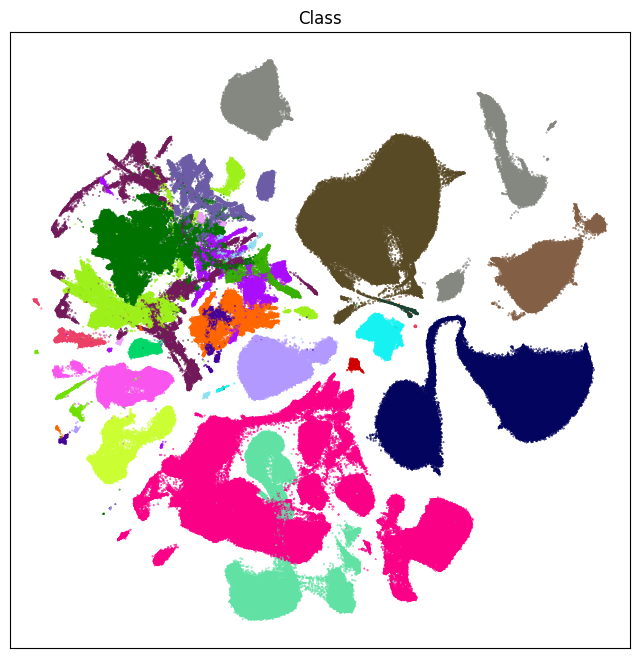

In [24]:
fig, ax = plot_umap(cell_extended['x'], cell_extended['y'], cc=cell_extended['class_color'])
res = ax.set_title("Class")
plt.show()

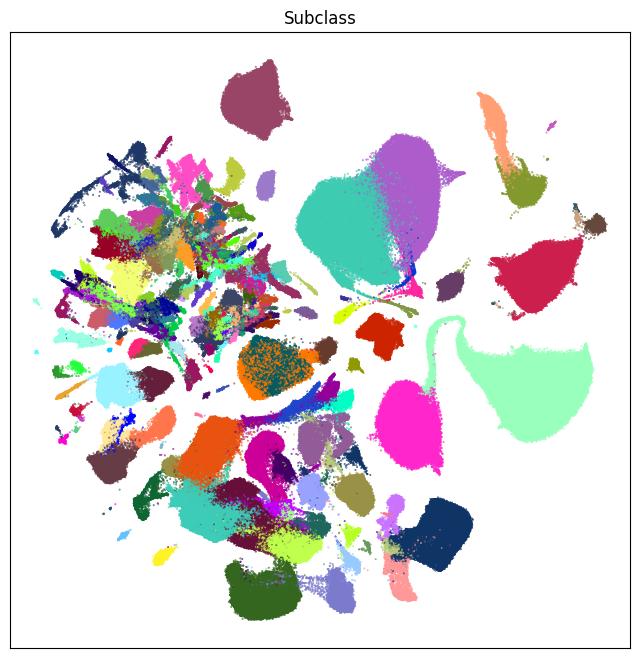

In [25]:
fig, ax = plot_umap(cell_extended['x'], cell_extended['y'], cc=cell_extended['subclass_color'])
res = ax.set_title("Subclass")
plt.show()

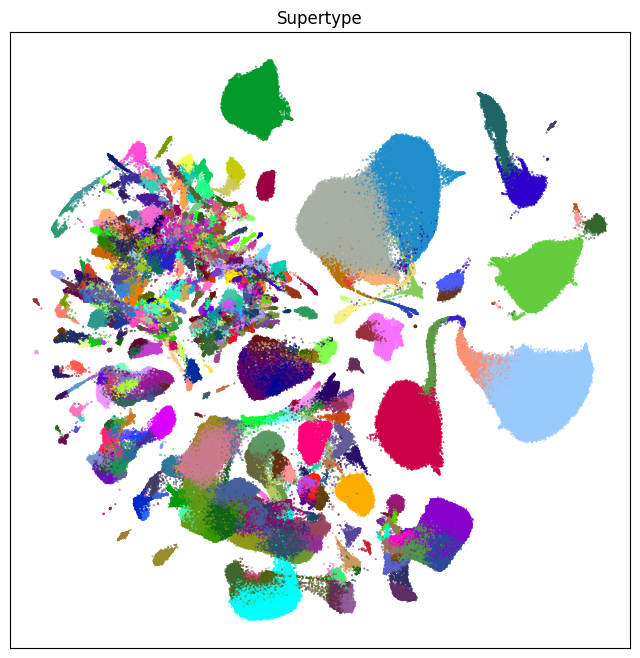

In [26]:
fig, ax = plot_umap(cell_extended['x'], cell_extended['y'], cc=cell_extended['supertype_color'])
res = ax.set_title("Supertype")
plt.show()

### Aggregating cluster and cells counts per term 

Finally in this walkthrough of the data, we'll explore the taxonomy a bit more. 

Now that we have information associated in each cluster and the full hierarchy of the taxonomy loaded, we can merge the cluster_info and cell mapping tables on their index (cluster_alias), producing a dataset describing the taxonomy. We'll use this to display counts of cells and clusters against various metadata. 

We'll need to load one more metadata containing the full mapping of Aging Mouse cluster to the WMB taxonomy. 

In [27]:
cluster_mapping = abc_cache.get_metadata_dataframe(
    directory='Zeng-Aging-Mouse-WMB-taxonomy',
    file_name='cluster_mapping',
    dtype={'cluster_label': str}
).set_index('cluster_alias')
cluster_mapping.head()

cluster_mapping.csv: 100%|██████████| 405k/405k [00:00<00:00, 1.74MMB/s]


,cluster_label,cluster_order,cluster_name,cluster_color,cluster_annotation_term_label,cluster_annotation_term_name,cluster_annotation_term_set_label,parent_term_label,parent_term_set_label,term_set_order,term_order,cluster_annotation_term_set_name,color_hex_triplet
cluster_alias,,,,,,,,,,,,,
1,CS20241021_0001,0,1_CLA-EPd-CTX Car3 Glut_1,#f7c27a,CS20230722_SUPT_0001,0001 CLA-EPd-CTX Car3 Glut_1,CCN20230722_SUPT,CS20230722_SUBC_001,CCN20230722_SUBC,3,0,supertype,#99822E
2,CS20241021_0002,1,2_IT EP-CLA Glut_1,#5c1a34,CS20230722_SUPT_0003,0003 IT EP-CLA Glut_1,CCN20230722_SUPT,CS20230722_SUBC_002,CCN20230722_SUBC,3,2,supertype,#994563
3,CS20241021_0003,2,3_IT EP-CLA Glut_1,#b96cf0,CS20230722_SUPT_0003,0003 IT EP-CLA Glut_1,CCN20230722_SUPT,CS20230722_SUBC_002,CCN20230722_SUBC,3,2,supertype,#994563
4,CS20241021_0004,3,4_IT EP-CLA Glut_1,#bff691,CS20230722_SUPT_0003,0003 IT EP-CLA Glut_1,CCN20230722_SUPT,CS20230722_SUBC_002,CCN20230722_SUBC,3,2,supertype,#994563
5,CS20241021_0005,4,5_IT EP-CLA Glut_1,#39fbfa,CS20230722_SUPT_0003,0003 IT EP-CLA Glut_1,CCN20230722_SUPT,CS20230722_SUBC_002,CCN20230722_SUBC,3,2,supertype,#994563


Merge in cluster info to get the full set of colors and neurotransmitter identities.

In [28]:
membership = cluster_mapping.join(cluster_info, rsuffix='_cl_info')
membership.head()

,cluster_label,cluster_order,cluster_name,cluster_color,cluster_annotation_term_label,cluster_annotation_term_name,cluster_annotation_term_set_label,parent_term_label,parent_term_set_label,term_set_order,...,proportion_adult_cells,proportion_aged_cells,odds_ratio,log2_odds_ratio,cluster_age_bias,max_region_of_interest_color,cluster_age_bias_color,neurotransmitter_combined_label,neurotransmitter_label,neurotransmitter_color
cluster_alias,,,,,,,,,,,,,,,,,,,,,
1,CS20241021_0001,0,1_CLA-EPd-CTX Car3 Glut_1,#f7c27a,CS20230722_SUPT_0001,0001 CLA-EPd-CTX Car3 Glut_1,CCN20230722_SUPT,CS20230722_SUBC_001,CCN20230722_SUBC,3,...,0.215041,0.784959,1.453797,0.539826,unassigned,#219866,#DADEDF,Glut,Glut,#2B93DF
2,CS20241021_0002,1,2_IT EP-CLA Glut_1,#5c1a34,CS20230722_SUPT_0003,0003 IT EP-CLA Glut_1,CCN20230722_SUPT,CS20230722_SUBC_002,CCN20230722_SUBC,3,...,0.484848,0.515152,0.421595,-1.246071,unassigned,#219866,#DADEDF,Glut,Glut,#2B93DF
3,CS20241021_0003,2,3_IT EP-CLA Glut_1,#b96cf0,CS20230722_SUPT_0003,0003 IT EP-CLA Glut_1,CCN20230722_SUPT,CS20230722_SUBC_002,CCN20230722_SUBC,3,...,0.407470,0.592530,0.576896,-0.793616,unassigned,#219866,#DADEDF,Glut,Glut,#2B93DF
4,CS20241021_0004,3,4_IT EP-CLA Glut_1,#bff691,CS20230722_SUPT_0003,0003 IT EP-CLA Glut_1,CCN20230722_SUPT,CS20230722_SUBC_002,CCN20230722_SUBC,3,...,0.516908,0.483092,0.371035,-1.430373,unassigned,#219866,#DADEDF,Glut,Glut,#2B93DF
5,CS20241021_0005,4,5_IT EP-CLA Glut_1,#39fbfa,CS20230722_SUPT_0003,0003 IT EP-CLA Glut_1,CCN20230722_SUPT,CS20230722_SUBC_002,CCN20230722_SUBC,3,...,0.305932,0.694068,0.900735,-0.150825,unassigned,#219866,#DADEDF,Glut,Glut,#2B93DF


One final set of data to create is to calculate the number of clusters that are members of a given supertype, subclass, and class in the taxonomy.

In [29]:
# Count the number of clusters associated with each cluster annotation term
term_cluster_count = membership.groupby(['cluster_annotation_term_label'])[['cluster_label']].count()
term_cluster_count.columns = ['number_of_clusters']
term_cluster_count.head()

,number_of_clusters
cluster_annotation_term_label,
CS20230722_CLAS_01,156
CS20230722_CLAS_02,38
CS20230722_CLAS_03,1
CS20230722_CLAS_04,6
CS20230722_CLAS_05,4


In [30]:
term_by_label = membership.set_index('cluster_annotation_term_label')
term_with_counts = term_by_label.join(term_cluster_count)
term_with_counts.head()

,cluster_label,cluster_order,cluster_name,cluster_color,cluster_annotation_term_name,cluster_annotation_term_set_label,parent_term_label,parent_term_set_label,term_set_order,term_order,...,proportion_aged_cells,odds_ratio,log2_odds_ratio,cluster_age_bias,max_region_of_interest_color,cluster_age_bias_color,neurotransmitter_combined_label,neurotransmitter_label,neurotransmitter_color,number_of_clusters
cluster_annotation_term_label,,,,,,,,,,,,,,,,,,,,,
CS20230722_SUPT_0001,CS20241021_0001,0,1_CLA-EPd-CTX Car3 Glut_1,#f7c27a,0001 CLA-EPd-CTX Car3 Glut_1,CCN20230722_SUPT,CS20230722_SUBC_001,CCN20230722_SUBC,3,0,...,0.784959,1.453797,0.539826,unassigned,#219866,#DADEDF,Glut,Glut,#2B93DF,1
CS20230722_SUPT_0003,CS20241021_0002,1,2_IT EP-CLA Glut_1,#5c1a34,0003 IT EP-CLA Glut_1,CCN20230722_SUPT,CS20230722_SUBC_002,CCN20230722_SUBC,3,2,...,0.515152,0.421595,-1.246071,unassigned,#219866,#DADEDF,Glut,Glut,#2B93DF,5
CS20230722_SUPT_0003,CS20241021_0003,2,3_IT EP-CLA Glut_1,#b96cf0,0003 IT EP-CLA Glut_1,CCN20230722_SUPT,CS20230722_SUBC_002,CCN20230722_SUBC,3,2,...,0.592530,0.576896,-0.793616,unassigned,#219866,#DADEDF,Glut,Glut,#2B93DF,5
CS20230722_SUPT_0003,CS20241021_0004,3,4_IT EP-CLA Glut_1,#bff691,0003 IT EP-CLA Glut_1,CCN20230722_SUPT,CS20230722_SUBC_002,CCN20230722_SUBC,3,2,...,0.483092,0.371035,-1.430373,unassigned,#219866,#DADEDF,Glut,Glut,#2B93DF,5
CS20230722_SUPT_0003,CS20241021_0005,4,5_IT EP-CLA Glut_1,#39fbfa,0003 IT EP-CLA Glut_1,CCN20230722_SUPT,CS20230722_SUBC_002,CCN20230722_SUBC,3,2,...,0.694068,0.900735,-0.150825,unassigned,#219866,#DADEDF,Glut,Glut,#2B93DF,5


Let's visualize cluster and cells counts for of the classification levels using bar plots.

In [31]:
def bar_plot_by_level_and_type(df, level=None, fig_width = 8.5, fig_height = 4):
    
    fig, ax = plt.subplots(1, 2)
    fig.set_size_inches(fig_width, fig_height)
    
    for idx, ctype in enumerate(['clusters', 'cells']):

        if level.lower().startswith('neurotransmitter'):
            level = 'Neurotransmitter'
            names = df['neurotransmitter_label']
            pred = np.ones(len(df), dtype=bool)
            colors = df['neurotransmitter_color']
            counts = df['number_of_%s' % ctype]
        else:
            pred = (df['cluster_annotation_term_set_name'] == level)
            names = df[pred]['cluster_annotation_term_name']
            colors = df[pred]['color_hex_triplet']
            counts = df[pred]['number_of_%s' % ctype]
        
        ax[idx].barh(names, counts, color=colors)
        ax[idx].set_title('Number of %s by %s' % (ctype, level)),
        ax[idx].set_xscale('log')

        if idx > 0 :
            ax[idx].set_yticklabels([])

    plt.show()

#### Neurotransmitter cluster and cell counts  

As seen below, most of the clusters in the study are glutamatergic, while the majority of cells are Nonneuronal. 

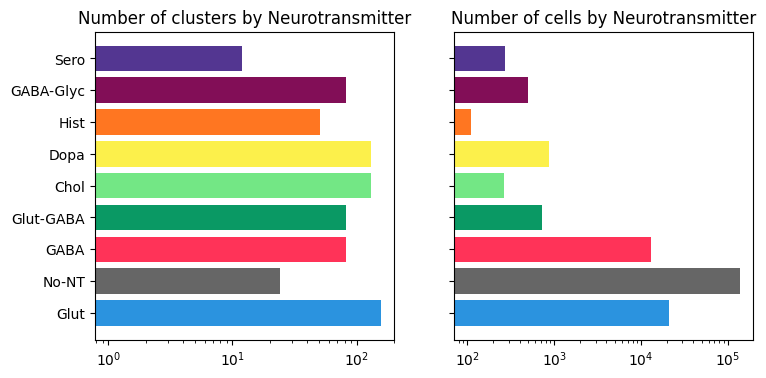

In [32]:
bar_plot_by_level_and_type(term_with_counts, 'neurotransmitter_label')

#### Class level cluster and cell counts 

Class "01 IT-ET" contains the largest number of clusters (~100), while class "30 Astro-Epen" contains the largest number of cells. 

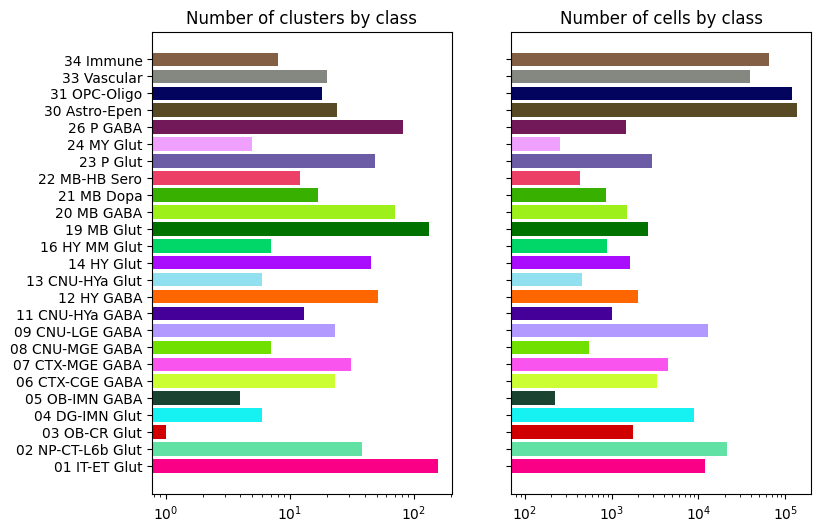

In [33]:
bar_plot_by_level_and_type(term_with_counts, 'class', 8.5, 6)

### Visualizing cluster and term distributions 

We can explore the relationship and distribution of clusters between term sets by creating a pivot table using pandas groupby function. Each row of the resulting DataFrame represents a cluster, each column represents a term set and the value in the table is the name of the term that has been associated with the cluster for that specific term set. 

In [34]:
pivot = membership.groupby(['cluster_alias', 'cluster_annotation_term_set_name'])['cluster_annotation_term_name'].first().unstack()
pivot = pivot.join(cluster_info)
pivot.head()

,class,subclass,supertype,number_of_cells,cluster_label,cluster_order,cluster_name,cluster_color,max_region_of_interest_label,proportion_max_region_of_interest_label,...,proportion_adult_cells,proportion_aged_cells,odds_ratio,log2_odds_ratio,cluster_age_bias,max_region_of_interest_color,cluster_age_bias_color,neurotransmitter_combined_label,neurotransmitter_label,neurotransmitter_color
cluster_alias,,,,,,,,,,,,,,,,,,,,,
1,01 IT-ET Glut,001 CLA-EPd-CTX Car3 Glut,0001 CLA-EPd-CTX Car3 Glut_1,851,CS20241021_0001,0,1_CLA-EPd-CTX Car3 Glut_1,#f7c27a,Isocortex - AI,0.831962,...,0.215041,0.784959,1.453797,0.539826,unassigned,#219866,#DADEDF,Glut,Glut,#2B93DF
2,01 IT-ET Glut,002 IT EP-CLA Glut,0003 IT EP-CLA Glut_1,330,CS20241021_0002,1,2_IT EP-CLA Glut_1,#5c1a34,Isocortex - AI,0.969697,...,0.484848,0.515152,0.421595,-1.246071,unassigned,#219866,#DADEDF,Glut,Glut,#2B93DF
3,01 IT-ET Glut,002 IT EP-CLA Glut,0003 IT EP-CLA Glut_1,589,CS20241021_0003,2,3_IT EP-CLA Glut_1,#b96cf0,Isocortex - AI,0.894737,...,0.407470,0.592530,0.576896,-0.793616,unassigned,#219866,#DADEDF,Glut,Glut,#2B93DF
4,01 IT-ET Glut,002 IT EP-CLA Glut,0003 IT EP-CLA Glut_1,207,CS20241021_0004,3,4_IT EP-CLA Glut_1,#bff691,Isocortex - AI,0.971014,...,0.516908,0.483092,0.371035,-1.430373,unassigned,#219866,#DADEDF,Glut,Glut,#2B93DF
5,01 IT-ET Glut,002 IT EP-CLA Glut,0003 IT EP-CLA Glut_1,2141,CS20241021_0005,4,5_IT EP-CLA Glut_1,#39fbfa,Isocortex - AI,0.987389,...,0.305932,0.694068,0.900735,-0.150825,unassigned,#219866,#DADEDF,Glut,Glut,#2B93DF


We can also obtain a cluster annotation color pivot table in the same way.

In [35]:
color = membership.groupby(['cluster_alias', 'cluster_annotation_term_set_name'])['color_hex_triplet'].first().unstack().fillna('#f9f9f9')
color.columns = ['%s_color' % x for x in color.columns]
color.head()

,class_color,subclass_color,supertype_color
cluster_alias,,,
1,#FA0087,#64c2fc,#99822E
2,#FA0087,#1F665D,#994563
3,#FA0087,#1F665D,#994563
4,#FA0087,#1F665D,#994563
5,#FA0087,#1F665D,#994563


In [36]:
pivot = pivot.join(color)

### Plotting distributions of clusters and cells by taxonomy level

For a given pair of term sets A and B, we compute a cluster count table where the rows are terms in term set A, columns are terms in term set B with the table values being the number of clusters that are shared between the terms. 

In [37]:
def distribution(A, B, B_color) :
    
    AxB = pivot.groupby([A, B])[['cluster_name']].count()
    AxB.columns = ['number_of_clusters']
    AxB = AxB.unstack().fillna(0)
    B_names = pivot[B].unique()
    B_colors = pd.Series(data=pivot[B_color].unique(), index=B_names)
    
    return AxB, B_names, B_colors

Function *stacked_bar_distribution* takes the results of *distribution* as input to create distribution stacked bar plot.


In [38]:
def stacked_bar_distribution(AxB, B_names, B_colors, fig_width = 6, fig_height = 6):
    """
    """

    fig, ax = plt.subplots()
    fig.set_size_inches(fig_width, fig_height)

    bottom = np.zeros(len(AxB))

    for i, col in enumerate(AxB.columns):
        ax.barh(AxB.index, AxB[col], left=bottom, label=col[1], color=B_colors.loc[col[1]])
        bottom += np.array(AxB[col])

    ax.set_title('Distribution of %s in each %s' % (AxB.columns.names[1], AxB.index.name))
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    plt.show()
    
    return fig, ax

#### Distribution of neurotransmitter clusters in each class

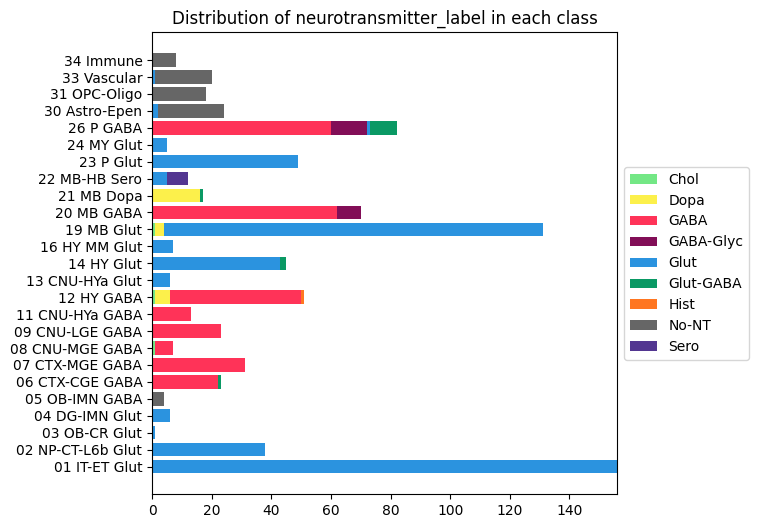

In [39]:
AxB, B_names, B_colors = distribution('class', 'neurotransmitter_label', 'neurotransmitter_color')
fig, ax = stacked_bar_distribution(AxB, B_names, B_colors, 6, 6)

#### Distribution of age enriched vs age depleted clusters

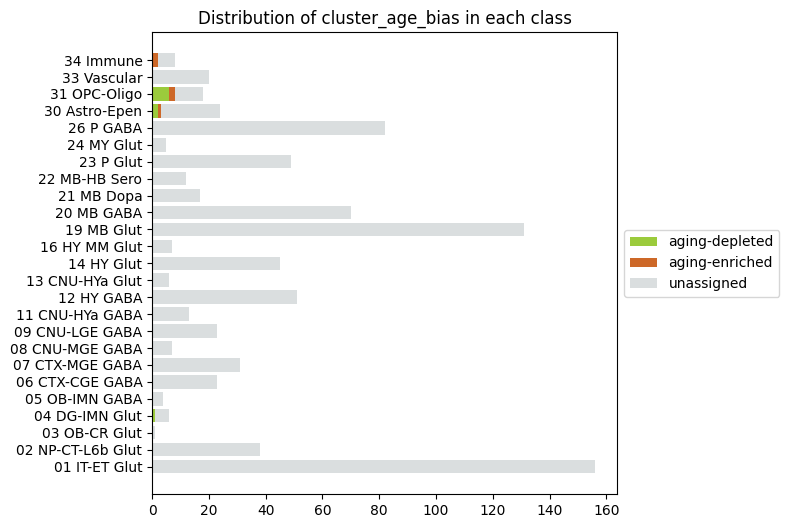

In [40]:
AxB, B_names, B_colors = distribution('class', 'cluster_age_bias', 'cluster_age_bias_color')
fig, ax = stacked_bar_distribution(AxB, B_names, B_colors, 6, 6)

#### Distribution of adult and aged cells

We can use the same groupby functionality as our distribution functions to this time sum up all the adult and age cells in each cluster and plot those versus class (or subclass, supertype). Note that there are ~600k aged cells vs ~400k adult cells in the data so an overall bias towards the aged cells is expected.

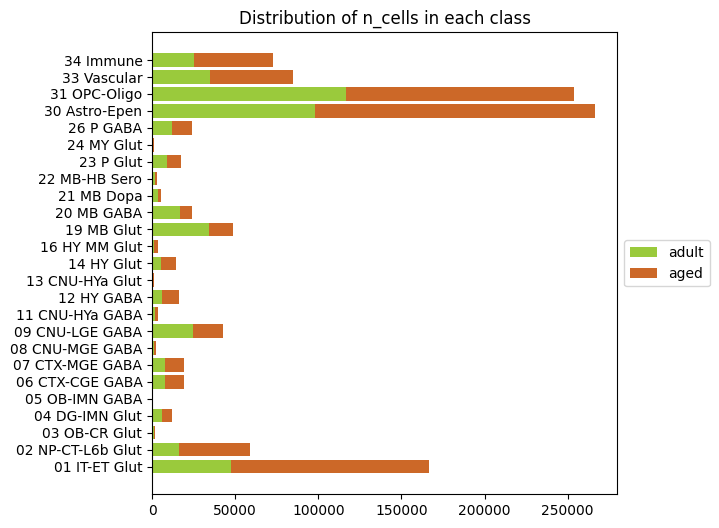

In [41]:
# Sum up the number of aged and adult cells.
n_adult = pivot.groupby(['class'])[['number_of_adult_cells']].sum()
n_aged = pivot.groupby(['class'])[['number_of_aged_cells']].sum()
adult_vs_aged = n_adult.join(n_aged)

# Rename columns and correctly label the aged/adult cells by color.
adult_vs_aged.columns = pd.MultiIndex.from_tuples(
    [('n_cells', 'adult'), ('n_cells', 'aged')],
    names=[None, 'n_cells'])
B_names = ['adult', 'aged']
B_colors = pd.Series(data=['#9ACA3C', '#CC6828'], index=B_names)

# Plot our barplot
fig, ax = stacked_bar_distribution(adult_vs_aged, B_names, B_colors, 6, 6)

### Visualizing the mouse whole brain taxonomy  

Term sets: class, subclass, supertype and cluster form a four-level mouse whole brain taxonomy. We can visualize the taxonomy as a sunburst diagram that shows the single inheritance hierarchy through a series of rings, that are sliced for each annotation term. Each ring corresponds to a level in the hierarchy. We have ordered the rings so that the class level is the outer most ring so that we can add in each class’s labels. Rings are sliced up and divided based on their hierarchical relationship to the parent slice. The angle of each slice is proportional to the number of clusters belonging to the term. 

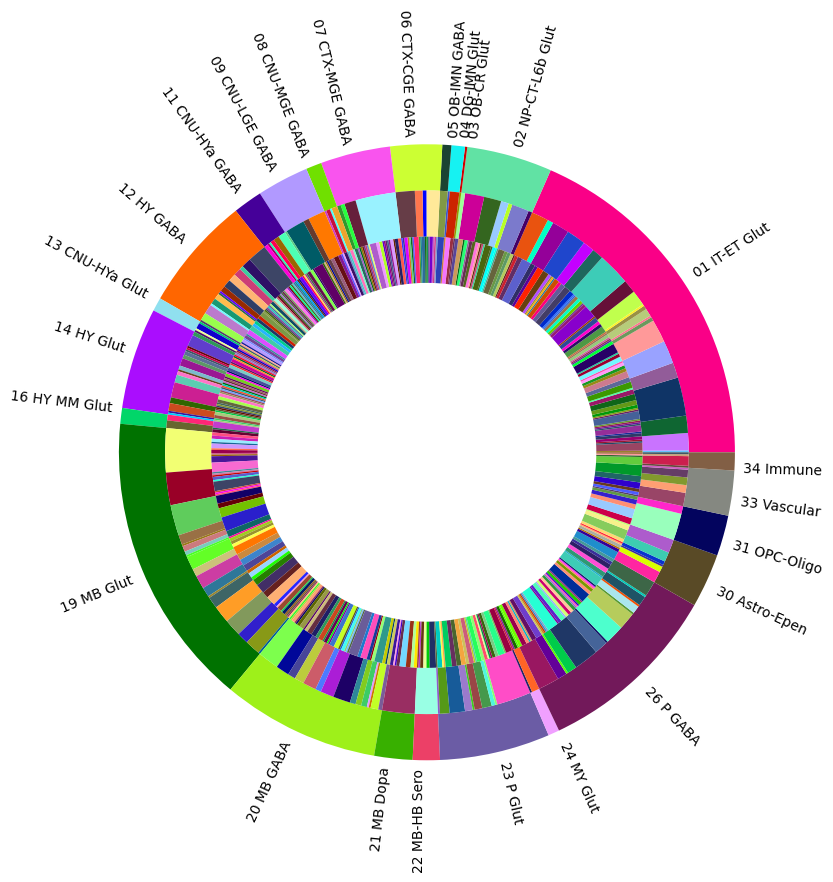

In [42]:
levels = ['class', 'subclass', 'supertype']
df = {}

for lvl in levels:
    pred = term_with_counts['cluster_annotation_term_set_name'] == lvl
    df[lvl] = term_with_counts[pred]
    df[lvl] = df[lvl].sort_values(['parent_term_label'])
    df[lvl] = df[lvl][~df[lvl].index.duplicated(keep='first')]

fig, ax = plt.subplots()
fig.set_size_inches(10, 10)
size = 0.15

for i, lvl in enumerate(levels):
    
    if lvl == 'class':
        ax.pie(df[lvl]['number_of_clusters'],
               colors=df[lvl]['color_hex_triplet'],
               labels=df[lvl]['cluster_annotation_term_name'],
               rotatelabels=True,
               labeldistance=1.025,
               radius=1,
               wedgeprops=dict(width=size, edgecolor=None),
               startangle=0)
    else:
        ax.pie(df[lvl]['number_of_clusters'],
               colors=df[lvl]['color_hex_triplet'],
               radius=1-i*size,
               wedgeprops=dict(width=size, edgecolor=None),
               startangle=0)

plt.show()

**In part 2 we'll focus on gene data including using the UMAP to plot gene expression locations as well as age Differential (ageDE) genes identified in Zeng et al.**